# Linear regression

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn import datasets
import matplotlib.pyplot as plt

In [ ]:
import linear_regression as L

In [ ]:
X, y = datasets.make_regression(n_samples=100, n_features=1, noise=20, random_state=4)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1234)

In [ ]:
fig = plt.figure(figsize=(8,6))
plt.scatter(X[:, 0], y, color = "b", marker = "o", s = 30)
plt.show()

In [ ]:
reg = L.LinearRegression(lr = 0.1, l2 = 1, l1 = 1)
reg.calc_params(X_train,y_train)
predictions = reg.predict(X_test)

In [ ]:
reg.coeff

In [ ]:
def mse(y_test, predictions):
    return np.mean((y_test-predictions)**2)

mse = mse(y_test, predictions)
print(mse)

In [ ]:
y_pred_line = reg.predict(X)
cmap = plt.get_cmap('viridis')
fig = plt.figure(figsize=(8,6))
m1 = plt.scatter(X_train, y_train, color=cmap(0.9), s=10)
m2 = plt.scatter(X_test, y_test, color=cmap(0.5), s=10)
plt.plot(X, y_pred_line, color='black', linewidth=2, label='Prediction')
plt.show()

# Logistic regression

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

# Generate dataset with 1 feature and 2 classes
X, y = make_classification(
    n_samples=200,       # number of samples
    n_features=1,        # only 1 feature
    n_informative=1,     # 1 informative feature
    n_redundant=0,       # no redundant features
    n_clusters_per_class=1,
    flip_y=0.03,         # add small noise in labels
    random_state=42
)

# Plot dataset
plt.scatter(X, y, c=y, cmap="bwr", alpha=0.7)
plt.xlabel("Feature X")
plt.ylabel("Target y")
plt.title("Synthetic Binary Classification Dataset (1 Feature)")
plt.show()


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1234)

In [ ]:
import logistic_regression as Lg
reg = Lg.LogisticRegression(lr = 0.1, l2 = 0,l1 = 0)
reg.calc_params(X_train,y_train)
y_pred = reg.predict(X_test)
y_prob = reg.predict_proba(X_test)

In [ ]:
reg.weights

In [ ]:
def accuracy(y_pred, y_test):
    return np.sum(y_pred==y_test)/len(y_test)

acc = accuracy(y_pred, y_test)
print(acc)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Extract the feature (only works if 1D feature)
X_feature = np.linspace(-3, 3, 50).reshape(50,1)

y_prob = reg.predict_proba(X_feature)
# Sort by feature for smooth curve


# Scatter plot of actual data
plt.scatter(X_test[:, 0], y_test, c=y_test, cmap="bwr", alpha=0.7, label="Data")

# Logistic regression S-curve
plt.plot(X_feature, y_prob, color="black", linewidth=2, label="Logistic Regression S-curve")

plt.xlabel("Feature X")
plt.ylabel("Predicted probability (y=1)")
plt.title("Logistic Regression Fit")
plt.legend()
plt.show()


# PCA

Shape of X: (150, 4)
Shape of transformed X: (150, 2)


C:\Users\niran\AppData\Local\Temp\ipykernel_1528\200972720.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  x1, x2, c=y, edgecolor="none", alpha=0.8, cmap=plt.cm.get_cmap("viridis", 3)


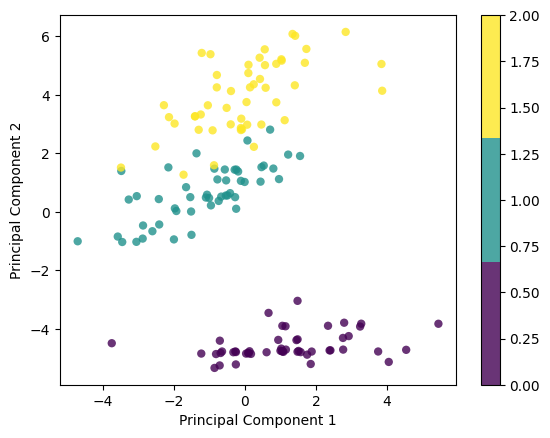

In [1]:
# Imports
import matplotlib.pyplot as plt
from sklearn import datasets
import PCA as p

# data = datasets.load_digits()
data = datasets.load_iris()
X = data.data
y = data.target

# Project the data onto the 2 primary principal components
pca = p.PCA(2)
pca.fit(X)
X_projected = pca.transform(X)

print("Shape of X:", X.shape)
print("Shape of transformed X:", X_projected.shape)

x1 = X_projected[:, 0]
x2 = X_projected[:, 1]

plt.scatter(
    x1, x2, c=y, edgecolor="none", alpha=0.8, cmap=plt.cm.get_cmap("viridis", 3)
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar()
plt.show()

# KNN

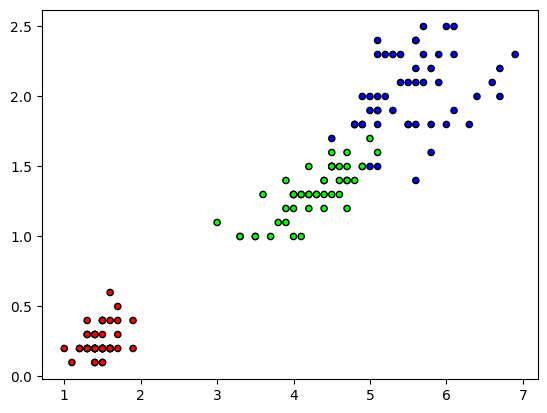

[np.int64(1), np.int64(2), np.int64(2), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(2), np.int64(1), np.int64(0), np.int64(2), np.int64(1), np.int64(0), np.int64(1), np.int64(2), np.int64(0), np.int64(2), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(2), np.int64(0), np.int64(2), np.int64(1), np.int64(2), np.int64(0)]
0.9666666666666667


In [ ]:
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import knn as k

cmap = ListedColormap(['#FF0000','#00FF00','#0000FF'])

iris = datasets.load_iris()
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1234)

plt.figure()
plt.scatter(X[:,2],X[:,3], c=y, cmap=cmap, edgecolor='k', s=20)
plt.show()


clf = k.KNN(k=5)
clf.fit(X_train, y_train)
predictions = clf.predict(X_test)

print(predictions)

acc = np.sum(predictions == y_test) / len(y_test)

print(acc)